In [1]:
# Cell 1: Import dependencies
import os
import sys
import numpy as np
import matplotlib.pyplot as plt

# Ensure local src/ package is accessible
sys.path.append(os.path.abspath(".."))
from src.allen_data.load_recording import (
    get_cell_metadata,
    list_available_sweeps,
    download_cell_data,
    load_sweep,
    validate_recording,
    detect_spikes_basic,
)

print("Dependencies successfully imported.")


Dependencies successfully imported.


In [2]:
# Cell 2: Define and load the selected neuron
specimen_id = 485909730
cache_dir = "../data/raw"

print(f"Loading data for Allen specimen ID: {specimen_id}")
data_set = download_cell_data(specimen_id, cache_dir=cache_dir)
print(f"Data set successfully loaded: {type(data_set).__name__}")


Loading data for Allen specimen ID: 485909730
Data set successfully loaded: NwbDataSet


In [3]:
# Cell 3: Print basic metadata
cell_meta = get_cell_metadata(specimen_id, cache_dir=cache_dir)

print("=" * 60)
print(f"Neuron Specimen ID : {cell_meta.get('id')}")
print(f"Cell Specimen Name : {cell_meta.get('name')}")
print(f"Species            : {cell_meta.get('species')}")
print(f"Brain Region       : {cell_meta.get('structure_area_abbrev')} (Area ID: {cell_meta.get('structure_area_id')})")
print(f"Cortical Layer     : Layer {cell_meta.get('structure_layer_name')}")
print(f"Dendrite Type      : {cell_meta.get('dendrite_type')}")
print(f"Transgenic Line    : {cell_meta.get('transgenic_line')}")
print(f"Donor ID           : {cell_meta.get('donor_id')}")
print("=" * 60)


Neuron Specimen ID : 485909730
Cell Specimen Name : Cux2-CreERT2;Ai14-205530.03.02.01
Species            : Mus musculus
Brain Region       : VISp (Area ID: 385)
Cortical Layer     : Layer 5
Dendrite Type      : spiny
Transgenic Line    : Cux2-CreERT2
Donor ID           : 485250100


In [4]:
# Cell 4: List available sweep numbers and characteristics
sweeps = list_available_sweeps(specimen_id, cache_dir=cache_dir)
print(f"Total sweeps recorded for specimen {specimen_id}: {len(sweeps)}")

long_squares = [s for s in sweeps if "Long Square" in s.get("stimulus_name", "")]
print(f"Found {len(long_squares)} 'Long Square' current-step sweeps:")
print(f"{'Sweep #':>8} | {'Stimulus Name':<15} | {'Amplitude (pA)':>15} | {'Spikes':>8}")
print("-" * 55)
for s in long_squares:
    amp_str = f"{s.get('stimulus_absolute_amplitude', 0.0):.1f}" if s.get('stimulus_absolute_amplitude') is not None else "N/A"
    spk_str = str(s.get('num_spikes', 0))
    print(f"{s['sweep_number']:>8} | {s.get('stimulus_name', ''):<15} | {amp_str:>15} | {spk_str:>8}")


Total sweeps recorded for specimen 485909730: 35
Found 12 'Long Square' current-step sweeps:
 Sweep # | Stimulus Name   |  Amplitude (pA) |   Spikes
-------------------------------------------------------
      24 | Long Square     |          -110.0 |     None
      25 | Long Square     |           -90.0 |     None
      26 | Long Square     |           -70.0 |     None
      27 | Long Square     |           -50.0 |     None
      28 | Long Square     |           -30.0 |     None
      29 | Long Square     |           -10.0 |     None
      30 | Long Square     |            10.0 |     None
      31 | Long Square     |            30.0 |     None
      32 | Long Square     |            50.0 |     None
      33 | Long Square     |            70.0 |        7
      34 | Long Square     |            90.0 |       12
      35 | Long Square     |           110.0 |       17


In [5]:
# Cell 5: Select one appropriate long current-step sweep
# We select Sweep 34: a 1.0 s depolarizing step of +90 pA yielding robust action potentials (12 spikes)
selected_sweep_number = 34
print(f"Selected Sweep Number: {selected_sweep_number}")
selected_sweep_meta = next(s for s in sweeps if s["sweep_number"] == selected_sweep_number)
print(f"Sweep {selected_sweep_number} stimulus: {selected_sweep_meta['stimulus_name']}, "
      f"amplitude: {selected_sweep_meta.get('stimulus_absolute_amplitude'):.1f} pA, "
      f"Allen spike count: {selected_sweep_meta.get('num_spikes')}")


Selected Sweep Number: 34
Sweep 34 stimulus: Long Square, amplitude: 90.0 pA, Allen spike count: 12


In [6]:
# Cell 6: Load stimulus, response, sampling rate
# load_sweep extracts the raw stimulus (Amperes) and response (Volts) arrays and validates data integrity
time, stimulus, response, sampling_rate = load_sweep(data_set, selected_sweep_number)
val_summary = validate_recording(time, stimulus, response, sampling_rate)

print(f"Sampling rate : {sampling_rate:.1f} Hz")
print(f"Data validated: {val_summary['valid']}")
print(f"Total samples : {len(response):,}")
print(f"Duration      : {val_summary['duration_seconds']:.3f} s")


Sampling rate : 200000.0 Hz
Data validated: True
Total samples : 1,604,001
Duration      : 8.020 s


In [7]:
# Cell 7: Create the time vector
# Verification and details of the time vector
dt = 1.0 / sampling_rate
print(f"Time step (dt)    : {dt * 1e6:.1f} microseconds")
print(f"Time vector range : [{time[0]:.6f}, {time[-1]:.6f}] seconds")
print(f"Length matches    : {len(time) == len(response)}")


Time step (dt)    : 5.0 microseconds
Time vector range : [0.000000, 8.020000] seconds
Length matches    : True


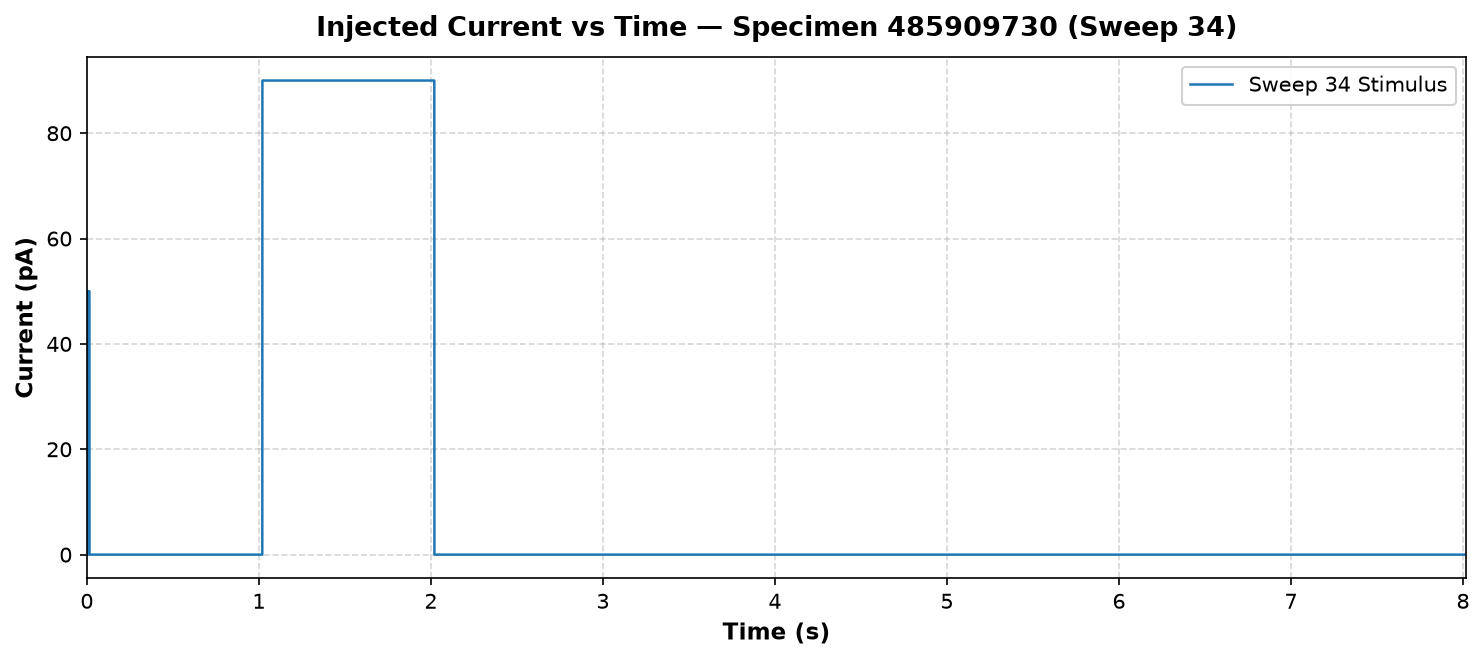

In [8]:
# Cell 8: Plot Injected Current vs Time
# Convert current to picoamperes (pA) for standard electrophysiology visualization
current_pA = stimulus * 1e12

fig, ax = plt.subplots(figsize=(10, 4.5), dpi=150)
ax.plot(time, current_pA, color='#1f77b4', linewidth=1.2, label=f"Sweep {selected_sweep_number} Stimulus")
ax.set_xlabel("Time (s)", fontsize=11, fontweight="bold")
ax.set_ylabel("Current (pA)", fontsize=11, fontweight="bold")
ax.set_title(f"Injected Current vs Time — Specimen {specimen_id} (Sweep {selected_sweep_number})", fontsize=13, fontweight="bold", pad=10)
ax.grid(True, linestyle="--", alpha=0.5)
ax.set_xlim(0, time[-1])
ax.legend(loc="upper right", framealpha=0.9)
plt.tight_layout()
plt.show()


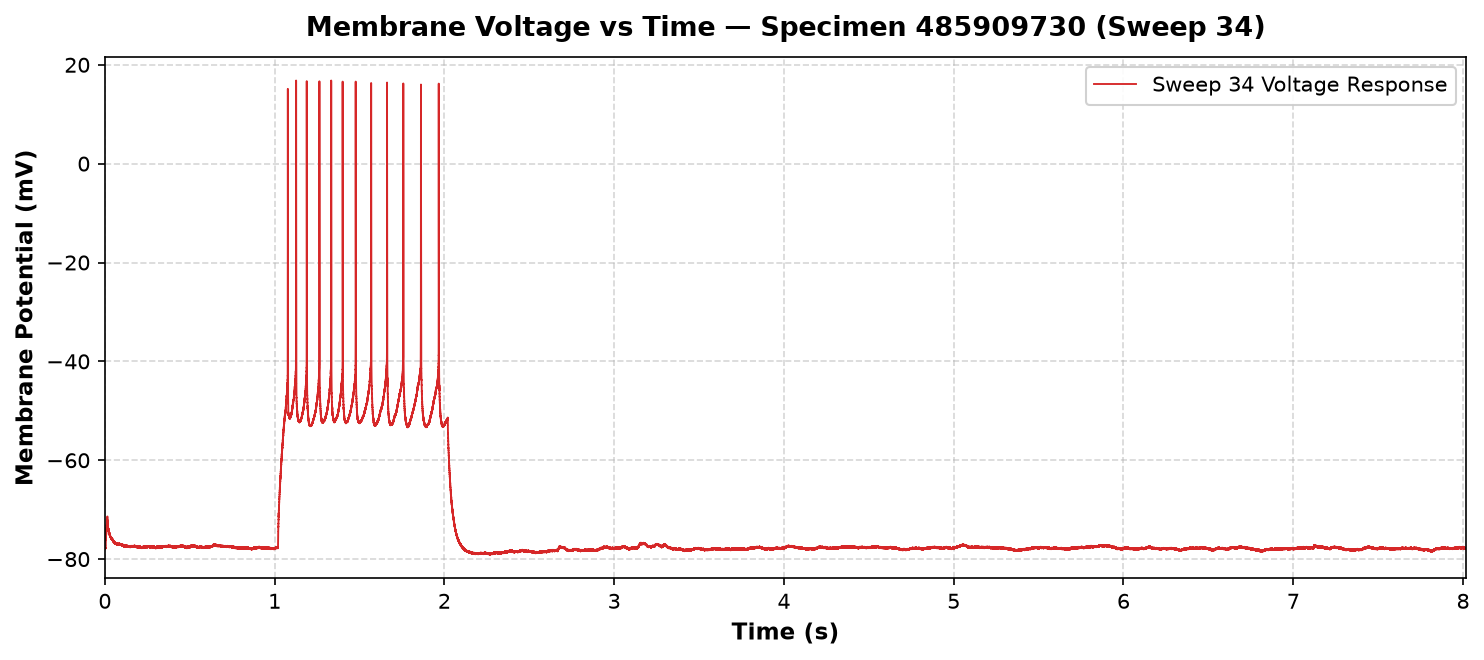

In [9]:
# Cell 9: Plot Membrane Voltage vs Time
# Convert response to millivolts (mV) for standard electrophysiology visualization
voltage_mV = response * 1e3

fig, ax = plt.subplots(figsize=(10, 4.5), dpi=150)
ax.plot(time, voltage_mV, color='#d62728', linewidth=0.9, label=f"Sweep {selected_sweep_number} Voltage Response")
ax.set_xlabel("Time (s)", fontsize=11, fontweight="bold")
ax.set_ylabel("Membrane Potential (mV)", fontsize=11, fontweight="bold")
ax.set_title(f"Membrane Voltage vs Time — Specimen {specimen_id} (Sweep {selected_sweep_number})", fontsize=13, fontweight="bold", pad=10)
ax.grid(True, linestyle="--", alpha=0.5)
ax.set_xlim(0, time[-1])
ax.legend(loc="upper right", framealpha=0.9)
plt.tight_layout()
plt.show()


In [10]:
# Cell 10: Print basic information
stim_min_pA = stimulus.min() * 1e12
stim_max_pA = stimulus.max() * 1e12
resp_min_mV = response.min() * 1e3
resp_max_mV = response.max() * 1e3
recording_duration = len(response) / sampling_rate

spk_count, _ = detect_spikes_basic(response, sampling_rate, threshold_v=-0.020)

print("=" * 65)
print("             STEP 1: RECORDING SUMMARY METRICS")
print("=" * 65)
print(f"Neuron ID (Specimen ID) : {specimen_id}")
print(f"Sweep ID (Sweep Number) : {selected_sweep_number}")
print(f"Sampling Rate           : {sampling_rate:.1f} Hz")
print(f"Number of Samples       : {len(response):,}")
print(f"Recording Duration      : {recording_duration:.3f} s")
print(f"Stimulus Range          : [{stim_min_pA:.2f}, {stim_max_pA:.2f}] pA")
print(f"Voltage Range           : [{resp_min_mV:.2f}, {resp_max_mV:.2f}] mV")
print(f"Action Potentials Count : {spk_count} spikes")
print("=" * 65)


             STEP 1: RECORDING SUMMARY METRICS
Neuron ID (Specimen ID) : 485909730
Sweep ID (Sweep Number) : 34
Sampling Rate           : 200000.0 Hz
Number of Samples       : 1,604,001
Recording Duration      : 8.020 s
Stimulus Range          : [0.00, 90.00] pA
Voltage Range           : [-79.09, 16.81] mV
Action Potentials Count : 12 spikes
